# Intern Performance Prediction
### Regression using Random Forest & XGBoost

In [1]:
# LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# LOAD DATA
file_path = '/content/drive/MyDrive/intern_dataset_realistic (1).csv'
df = pd.read_csv(file_path)

print('Dataset Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows:')
display(df.head())
print('\nMissing Values:')
print(df.isnull().sum())
print('\nSummary Statistics:')
display(df.describe())

Dataset Shape: (10000, 5)

Columns: ['Intern_ID', 'Completion_Time', 'Feedback_Rating', 'Attendance', 'Performance_Score']

First 5 rows:


,Intern_ID,Completion_Time,Feedback_Rating,Attendance,Performance_Score
0,INT0001,3.26,4.09,86.50,70.98
1,INT0002,NaN,1.33,59.23,42.16
2,INT0003,5.78,NaN,42.98,49.89
3,INT0004,4.28,1.43,83.16,68.49
4,INT0005,1.53,1.91,74.10,77.51



Missing Values:
Intern_ID              0
Completion_Time      396
Feedback_Rating      392
Attendance           390
Performance_Score      0
dtype: int64

Summary Statistics:


,Completion_Time,Feedback_Rating,Attendance,Performance_Score
count,9604.000000,9608.000000,9610.000000,10000.000000
mean,3.958567,2.909313,62.769768,67.808159
std,1.738279,1.312825,26.614348,15.170590
min,1.000000,1.000000,0.000000,25.950000
25%,2.460000,1.800000,52.692500,56.947500
50%,3.920000,2.870000,66.830000,67.830000
75%,5.450000,4.000000,82.857500,78.870000
max,7.000000,5.000000,100.000000,100.000000


In [6]:
# DATA CLEANING
# Impute missing values with median robust to outliers
for col in ['Completion_Time', 'Feedback_Rating', 'Attendance']:
    median_val = df[col].median()
    missing_count = df[col].isnull().sum()
    df[col].fillna(median_val, inplace=True)
    print(f'{col}: filled {missing_count} missing values with median={median_val:.2f}')

print('\nMissing values after cleaning:')
print(df.isnull().sum())

Completion_Time: filled 396 missing values with median=3.92
Feedback_Rating: filled 392 missing values with median=2.87
Attendance: filled 390 missing values with median=66.83

Missing values after cleaning:
Intern_ID            0
Completion_Time      0
Feedback_Rating      0
Attendance           0
Performance_Score    0
dtype: int64


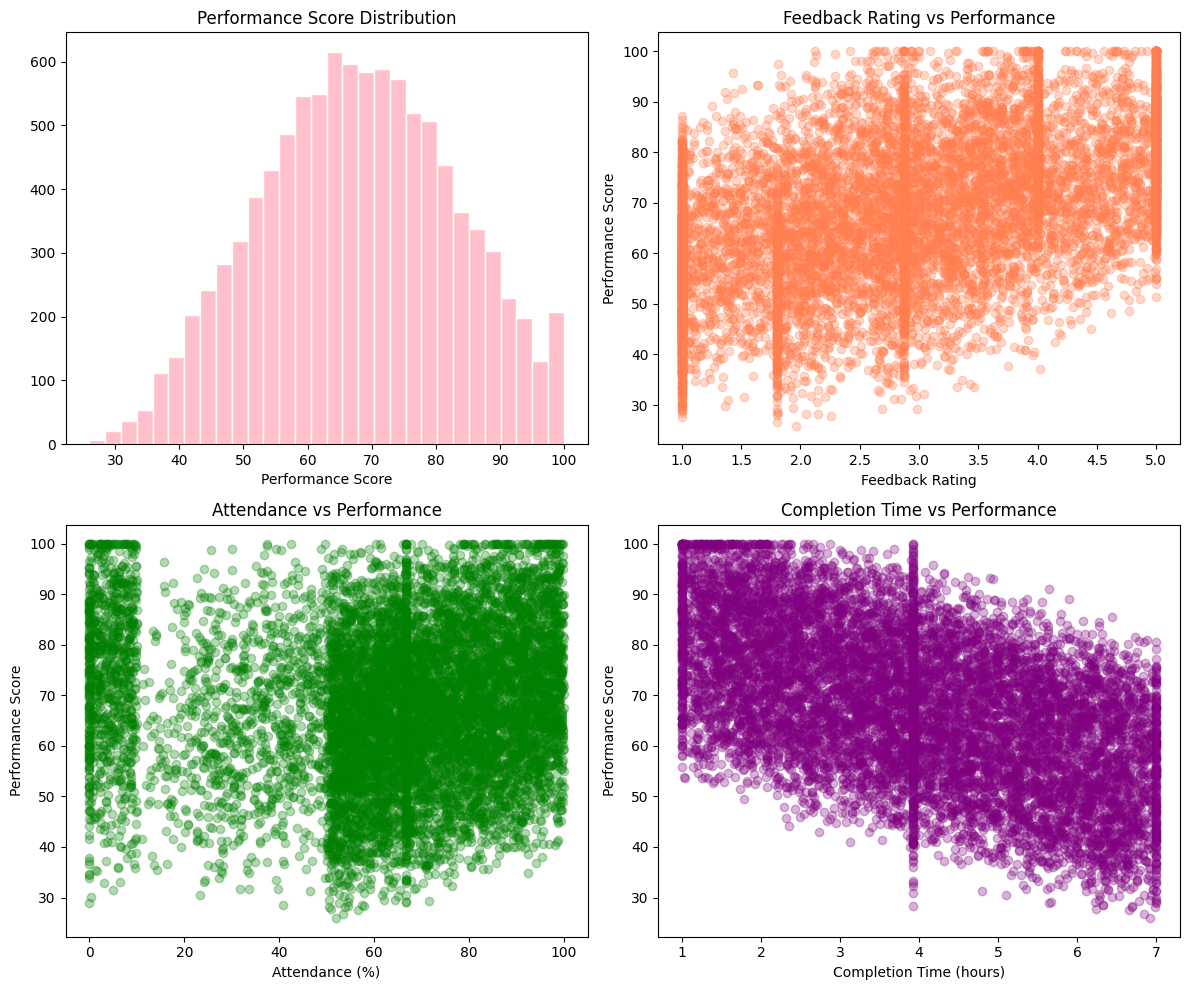

In [12]:
# EDA
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribution of target
axes[0, 0].hist(df['Performance_Score'], bins=30, color='pink', edgecolor='white')
axes[0, 0].set_title('Performance Score Distribution')
axes[0, 0].set_xlabel('Performance Score')

# Feedback vs Performance
axes[0, 1].scatter(df['Feedback_Rating'], df['Performance_Score'], alpha=0.3, color='coral')
axes[0, 1].set_title('Feedback Rating vs Performance')
axes[0, 1].set_xlabel('Feedback Rating')
axes[0, 1].set_ylabel('Performance Score')

# Attendance vs Performance
axes[1, 0].scatter(df['Attendance'], df['Performance_Score'], alpha=0.3, color='green')
axes[1, 0].set_title('Attendance vs Performance')
axes[1, 0].set_xlabel('Attendance (%)')
axes[1, 0].set_ylabel('Performance Score')

# Completion Time vs Performance
axes[1, 1].scatter(df['Completion_Time'], df['Performance_Score'], alpha=0.3, color='purple')
axes[1, 1].set_title('Completion Time vs Performance')
axes[1, 1].set_xlabel('Completion Time (hours)')
axes[1, 1].set_ylabel('Performance Score')

plt.tight_layout()
plt.show()

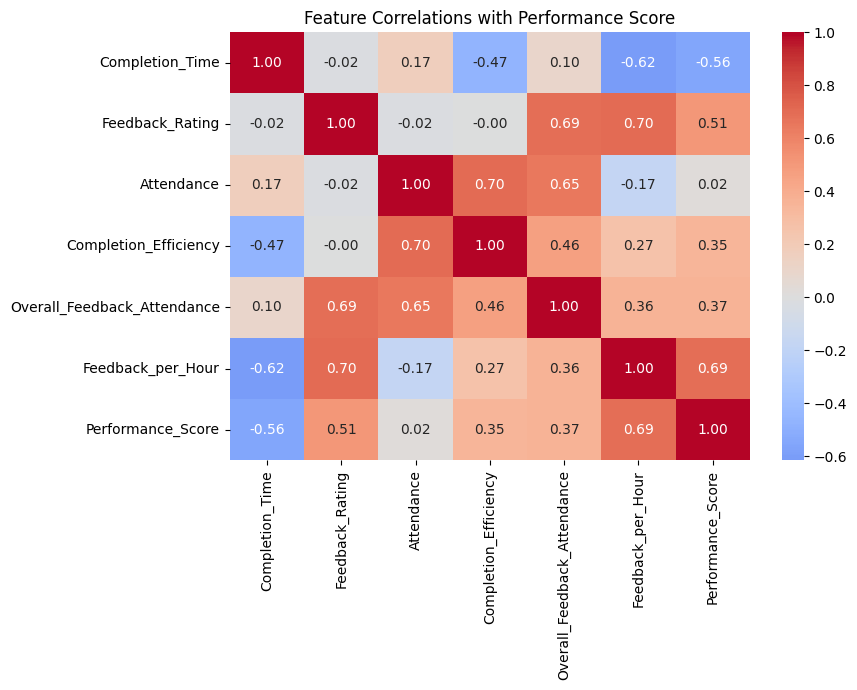

Features used: ['Completion_Time', 'Feedback_Rating', 'Attendance', 'Completion_Efficiency', 'Overall_Feedback_Attendance', 'Feedback_per_Hour']


In [13]:
# FEATURE ENGINEERING
# Original features + 2 new derived features
df['Completion_Efficiency'] = df['Attendance'] / (df['Completion_Time'] + 1)   # avoid div/0
df['Overall_Feedback_Attendance'] = df['Feedback_Rating'] * df['Attendance'] / 100
df['Feedback_per_Hour'] = df['Feedback_Rating'] / (df['Completion_Time'] + 1)  # NEW: quality per time

features = [
    'Completion_Time',
    'Feedback_Rating',
    'Attendance',
    'Completion_Efficiency',
    'Overall_Feedback_Attendance',
    'Feedback_per_Hour'   # improvement
]

# Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df[features + ['Performance_Score']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Feature Correlations with Performance Score')
plt.tight_layout()
plt.show()

print('Features used:', features)

In [14]:
# TRAIN-TEST SPLIT
X = df[features]
y = df['Performance_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

Training samples : 8000
Testing samples  : 2000


In [16]:
# MODEL TRAINING

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,   # improvement: prevents overfitting
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Random Forest trained!')

# XGBoost (improved hyperparameters)
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,   # improvement: smaller lr = better generalization
    max_depth=5,
    subsample=0.8,        # improvement: row sampling
    colsample_bytree=0.8, # improvement: feature sampling
    random_state=42,
    eval_metric='rmse'
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
print('XGBoost trained!')

Random Forest trained!
XGBoost trained!


In [17]:
# EVALUATION
def evaluate_model(model, X_test, y_test, X_full, y_full, name):
    pred = model.predict(X_test)
    cv_r2 = cross_val_score(model, X_full, y_full, cv=5, scoring='r2').mean()  # NEW: cross-validation
    print(f'\n=== {name} ===')
    print(f'RMSE    : {np.sqrt(mean_squared_error(y_test, pred)):.2f}')
    print(f'MAE     : {mean_absolute_error(y_test, pred):.2f}')
    print(f'R²      : {r2_score(y_test, pred):.4f}')
    print(f'CV R²   : {cv_r2:.4f}  <- 5-fold cross-validation (more reliable)')
    return pred

rf_pred  = evaluate_model(rf,        X_test, y_test, X, y, 'Random Forest')
xgb_pred = evaluate_model(xgb_model, X_test, y_test, X, y, 'XGBoost')


=== Random Forest ===
RMSE    : 9.40
MAE     : 7.57
R²      : 0.6085
CV R²   : 0.6060  <- 5-fold cross-validation (more reliable)

=== XGBoost ===
RMSE    : 9.20
MAE     : 7.39
R²      : 0.6247
CV R²   : 0.6204  <- 5-fold cross-validation (more reliable)


In [18]:
# SAVE MODELS
import joblib, os

os.makedirs('intern_model', exist_ok=True)

joblib.dump(rf,        'intern_model/random_forest_model.pkl')
joblib.dump(xgb_model, 'intern_model/xgboost_model.pkl')
joblib.dump(features,  'intern_model/features.pkl')

metrics = {
    'rf':  {'rmse': float(np.sqrt(mean_squared_error(y_test, rf_pred))),
            'mae':  float(mean_absolute_error(y_test, rf_pred)),
            'r2':   float(r2_score(y_test, rf_pred))},
    'xgb': {'rmse': float(np.sqrt(mean_squared_error(y_test, xgb_pred))),
            'mae':  float(mean_absolute_error(y_test, xgb_pred)),
            'r2':   float(r2_score(y_test, xgb_pred))}
}
joblib.dump(metrics, 'intern_model/model_metrics.pkl')
print("✅ Models saved!")

✅ Models saved!


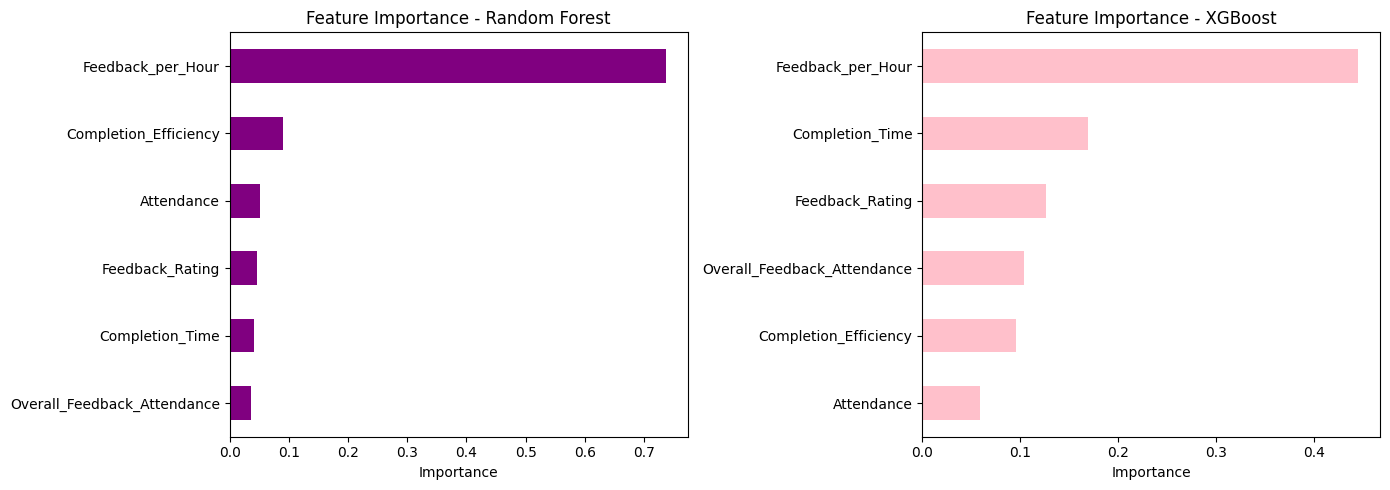

In [20]:
#FEATURE IMPORTANCE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest importance
rf_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
rf_imp.plot(kind='barh', ax=axes[0], color='purple')
axes[0].set_title('Feature Importance - Random Forest')
axes[0].set_xlabel('Importance')

# XGBoost importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=axes[1], color='pink')
axes[1].set_title('Feature Importance - XGBoost')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

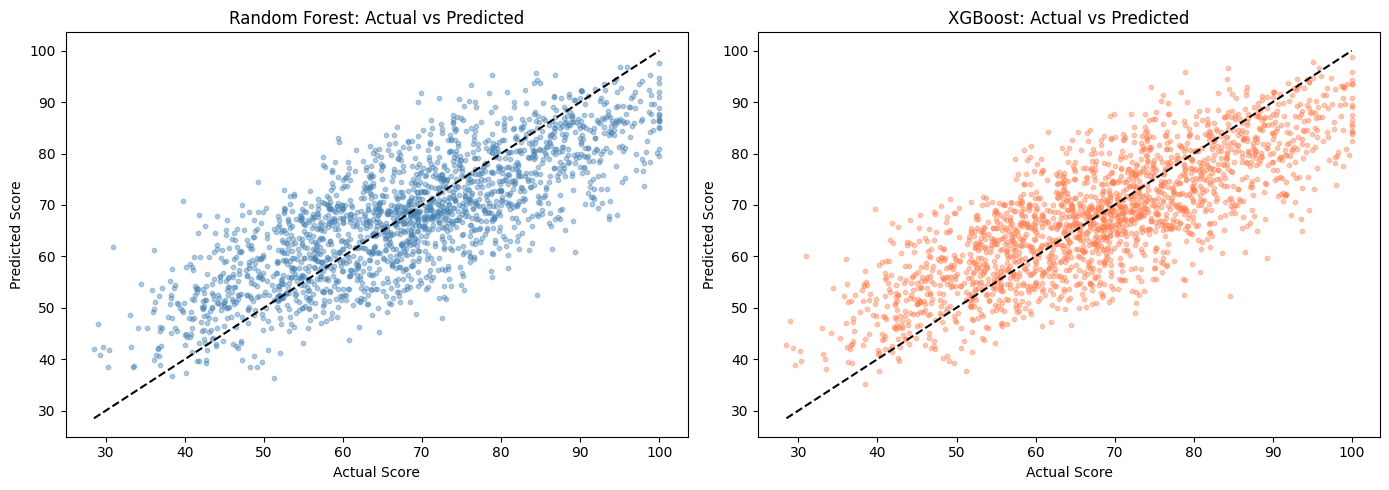

In [21]:
# ACTUAL vs PREDICTED PLOT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, name, color in zip(
    axes,
    [rf_pred, xgb_pred],
    ['Random Forest', 'XGBoost'],
    ['steelblue', 'coral']
):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=10)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'k--', lw=1.5)
    ax.set_xlabel('Actual Score')
    ax.set_ylabel('Predicted Score')
    ax.set_title(f'{name}: Actual vs Predicted')

plt.tight_layout()
plt.show()

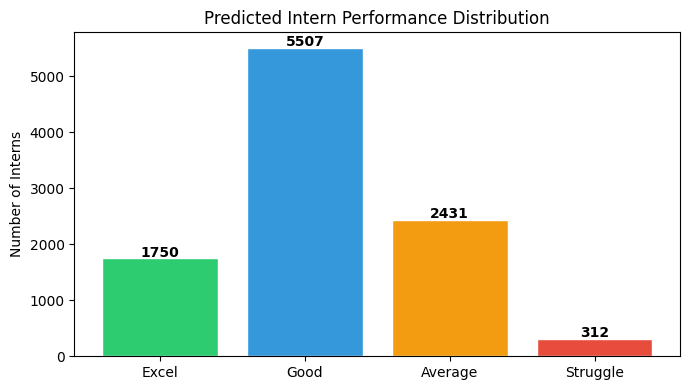


Predicted Distribution:
Predicted_Category
Good        5507
Average     2431
Excel       1750
Struggle     312
Name: count, dtype: int64


In [22]:
# PERFORMANCE CLASSIFICATION
# Use best model (XGBoost) for final predictions
df['Predicted_Score'] = xgb_model.predict(X)

def performance_category(score):
    if score >= 80:   return 'Excel'
    elif score >= 60: return 'Good'
    elif score >= 45: return 'Average'
    else:             return 'Struggle'

df['Predicted_Category'] = df['Predicted_Score'].apply(performance_category)

# Distribution plot
plt.figure(figsize=(7, 4))
order = ['Excel', 'Good', 'Average', 'Struggle']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
counts = df['Predicted_Category'].value_counts().reindex(order)
plt.bar(counts.index, counts.values, color=colors, edgecolor='white')
plt.title('Predicted Intern Performance Distribution')
plt.ylabel('Number of Interns')
for i, (k, v) in enumerate(counts.items()):
    plt.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nPredicted Distribution:')
print(df['Predicted_Category'].value_counts())

In [23]:
# ================== 12. FINAL SUMMARY REPORT ==================
print('=' * 45)
print('         INTERN PERFORMANCE REPORT')
print('=' * 45)

print('\nTop 10 Interns Likely to EXCEL:')
display(df[df['Predicted_Category'] == 'Excel']
          [['Intern_ID', 'Attendance', 'Feedback_Rating', 'Predicted_Score']]
          .sort_values('Predicted_Score', ascending=False).head(10))

print('\nTop 10 Interns Likely to STRUGGLE:')
display(df[df['Predicted_Category'] == 'Struggle']
          [['Intern_ID', 'Attendance', 'Feedback_Rating', 'Predicted_Score']]
          .sort_values('Predicted_Score').head(10))

# Save results to CSV
output_cols = ['Intern_ID', 'Completion_Time', 'Feedback_Rating',
               'Attendance', 'Performance_Score', 'Predicted_Score', 'Predicted_Category']
df[output_cols].to_csv('intern_predictions.csv', index=False)
print('\nResults saved to intern_predictions.csv')

         INTERN PERFORMANCE REPORT

Top 10 Interns Likely to EXCEL:


,Intern_ID,Attendance,Feedback_Rating,Predicted_Score
8376,INT8377,98.94,5.0,99.079689
4420,INT4421,96.83,5.0,98.880859
449,INT0450,96.09,5.0,98.839432
9091,INT9092,96.89,4.0,98.719124
2270,INT2271,97.00,5.0,98.714088
9079,INT9080,98.08,5.0,98.525864
2413,INT2414,0.73,4.0,98.413757
9571,INT9572,99.60,5.0,97.812805
1402,INT1403,2.74,5.0,97.720901
9973,INT9974,99.86,5.0,97.691116



Top 10 Interns Likely to STRUGGLE:


,Intern_ID,Attendance,Feedback_Rating,Predicted_Score
5109,INT5110,50.48,1.80,33.435768
6823,INT6824,52.48,1.80,34.470425
7250,INT7251,51.61,1.80,35.042408
6081,INT6082,51.06,1.80,35.256107
1700,INT1701,52.69,1.00,35.261963
7357,INT7358,50.60,1.80,35.418598
5060,INT5061,53.55,1.80,35.462578
473,INT0474,52.60,1.80,35.560837
8812,INT8813,51.16,1.81,36.256107
5317,INT5318,62.99,1.00,36.386032



Results saved to intern_predictions.csv
